# Wine Cultivar Analysis: which chemical measurements tell three wines apart?

**Business scenario (hypothetical):** a wine-quality laboratory receives bottles whose grape cultivar must be verified. Checking by hand is slow, so the lab would like to know whether the **chemical analysis it already runs** is enough to recognise the cultivar, and **which measurements matter most**.

The data is the classic *Wine* dataset (UCI Machine Learning Repository, distributed with scikit-learn): 178 wines grown in the same region of Italy and derived from three different cultivars, each described by 13 chemical measurements.

**Questions this notebook answers**

1. Which measurements differ most between the three cultivars?
2. Can a simple model recognise the cultivar from them, and how reliable is it compared with a naive rule?
3. How much does data preparation (scaling the measurements) matter?
4. How much can we trust a single accuracy figure on a dataset this small?

The notebook is written for a reader who wants the findings first: each section ends with a plain-language takeaway, and the modelling part is deliberately short.

**Data dictionary** (names as they appear in scikit-learn):

| Measurement | Meaning |
|---|---|
| `alcohol` | Alcohol content |
| `malic_acid` | Malic acid |
| `ash` | Ash |
| `alcalinity_of_ash` | Alkalinity of the ash |
| `magnesium` | Magnesium |
| `total_phenols` | Total phenols |
| `flavanoids` | Flavanoids (a family of phenols) |
| `nonflavanoid_phenols` | Non-flavanoid phenols |
| `proanthocyanins` | Proanthocyanins |
| `color_intensity` | Colour intensity |
| `hue` | Hue |
| `od280/od315_of_diluted_wines` | Optical-density ratio of the diluted wine |
| `proline` | Proline (an amino acid) |

The target has three classes, called `class_0`, `class_1` and `class_2` in the source data. They are shown as **Cultivar 0, 1 and 2** below, because the original dataset does not name the cultivars.

## Setup

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     GridSearchCV, cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Global seed, used by the split, the cross-validation and the stochastic models
RANDOM_STATE = 2718

# Colour palette used throughout the notebook
CULTIVARS = {0: "Cultivar 0", 1: "Cultivar 1", 2: "Cultivar 2"}
PALETTE = {"Cultivar 0": "#0f2744", "Cultivar 1": "#1b7f8c", "Cultivar 2": "#7fe3d6"}
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 1. Loading and first inspection

In [2]:
wine = load_wine(as_frame=True)
X, y = wine.data, wine.target

print(f"{X.shape[0]} wines, {X.shape[1]} measurements")
print(f"Missing values: {int(X.isna().sum().sum())}")
print(f"Duplicated rows: {int(X.duplicated().sum())}")
print(f"Data types: {sorted(X.dtypes.astype(str).unique())}")
X.head()

178 wines, 13 measurements
Missing values: 0
Duplicated rows: 0
Data types: ['float64']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


The dataset is complete (no missing values, no duplicates) and every measurement is numeric, so no cleaning or encoding is needed. With only 178 wines, results will be sensitive to how the data is split, which is why the evaluation later relies on repeated validation instead of a single score.

In [3]:
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


The measurements live on very different scales: `alcohol` is around 13 while `proline` ranges from about 280 to 1,680. Distance-based methods would let `proline` dominate, so the measurements will be standardized before modelling. We will test this assumption instead of simply stating it.

## 2. Train/test split
The test set is set aside **before any exploration**, so that nothing learned in the analysis can leak into the final evaluation. The split is stratified, which keeps the three cultivars in the same proportions in both parts (70% training, 30% test).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

balance = pd.DataFrame({
    "Full dataset": y.map(CULTIVARS).value_counts(normalize=True),
    "Training set": y_train.map(CULTIVARS).value_counts(normalize=True),
    "Test set": y_test.map(CULTIVARS).value_counts(normalize=True),
}).sort_index().mul(100).round(1)
balance.index.name = "% of wines"
print(f"Training set: {len(X_train)} wines | Test set: {len(X_test)} wines")
balance

Training set: 124 wines | Test set: 54 wines


,Full dataset,Training set,Test set
% of wines,,,
Cultivar 0,33.1,33.1,33.3
Cultivar 1,39.9,40.3,38.9
Cultivar 2,27.0,26.6,27.8


The three cultivars are reasonably balanced (roughly 40% / 33% / 27%), so there is no need for special handling of the classes, and accuracy is a meaningful metric. Macro-F1 is reported next to it as a check.

## 3. What distinguishes the cultivars?
From here on, all exploration uses the **training set only**.

### 3.1 Average profile of each cultivar

In [5]:
train = X_train.assign(cultivar=y_train.map(CULTIVARS))
profile = train.groupby("cultivar").mean().T.round(2)
profile

cultivar,Cultivar 0,Cultivar 1,Cultivar 2
alcohol,13.72,12.27,13.15
malic_acid,1.94,2.00,3.41
ash,2.44,2.23,2.43
alcalinity_of_ash,16.83,20.34,21.53
magnesium,105.71,94.30,98.61
total_phenols,2.79,2.31,1.67
flavanoids,2.91,2.09,0.76
nonflavanoid_phenols,0.29,0.37,0.45
proanthocyanins,1.89,1.62,1.18
color_intensity,5.51,3.10,7.51


### 3.2 How much of each measurement's variation is explained by the cultivar?
To rank the measurements by how well they separate the cultivars, we use the share of the total variation that is explained by the cultivar group.
A value of 0 means the cultivar tells us nothing about the measurement, and a value of 1 means the cultivars are perfectly separated on it. This is more suitable than a Pearson correlation with the class label, because the cultivar is a category and its numeric coding (0, 1, 2) has no order.

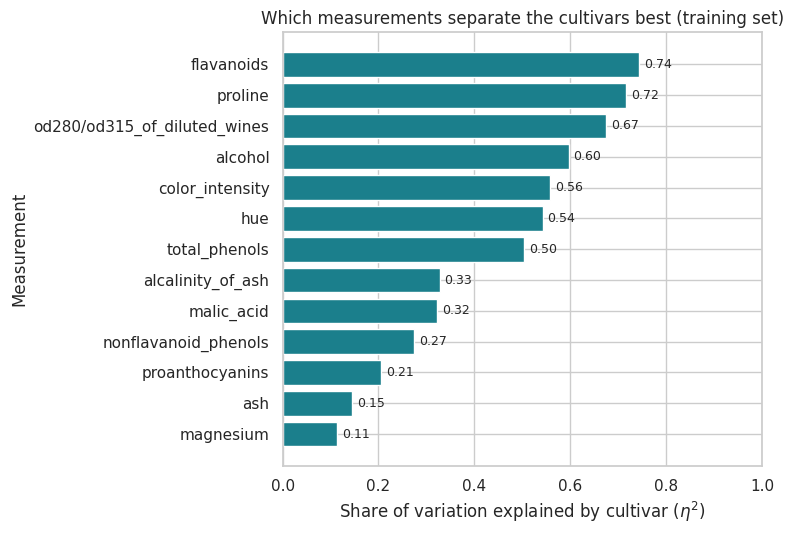

In [6]:
def eta_squared(values, groups):
    grand_mean = values.mean()
    ss_between = sum(len(values[groups == g]) * (values[groups == g].mean() - grand_mean) ** 2
                     for g in groups.unique())
    ss_total = ((values - grand_mean) ** 2).sum()
    return ss_between / ss_total

eta = pd.Series({c: eta_squared(X_train[c], y_train) for c in X_train.columns}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(eta.index[::-1], eta.values[::-1], color="#1b7f8c")
for i, v in enumerate(eta.values[::-1]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("Share of variation explained by cultivar ($\\eta^2$)")
ax.set_ylabel("Measurement")
ax.set_title("Which measurements separate the cultivars best (training set)")
plt.tight_layout()
plt.show()

### 3.3 Distributions by cultivar

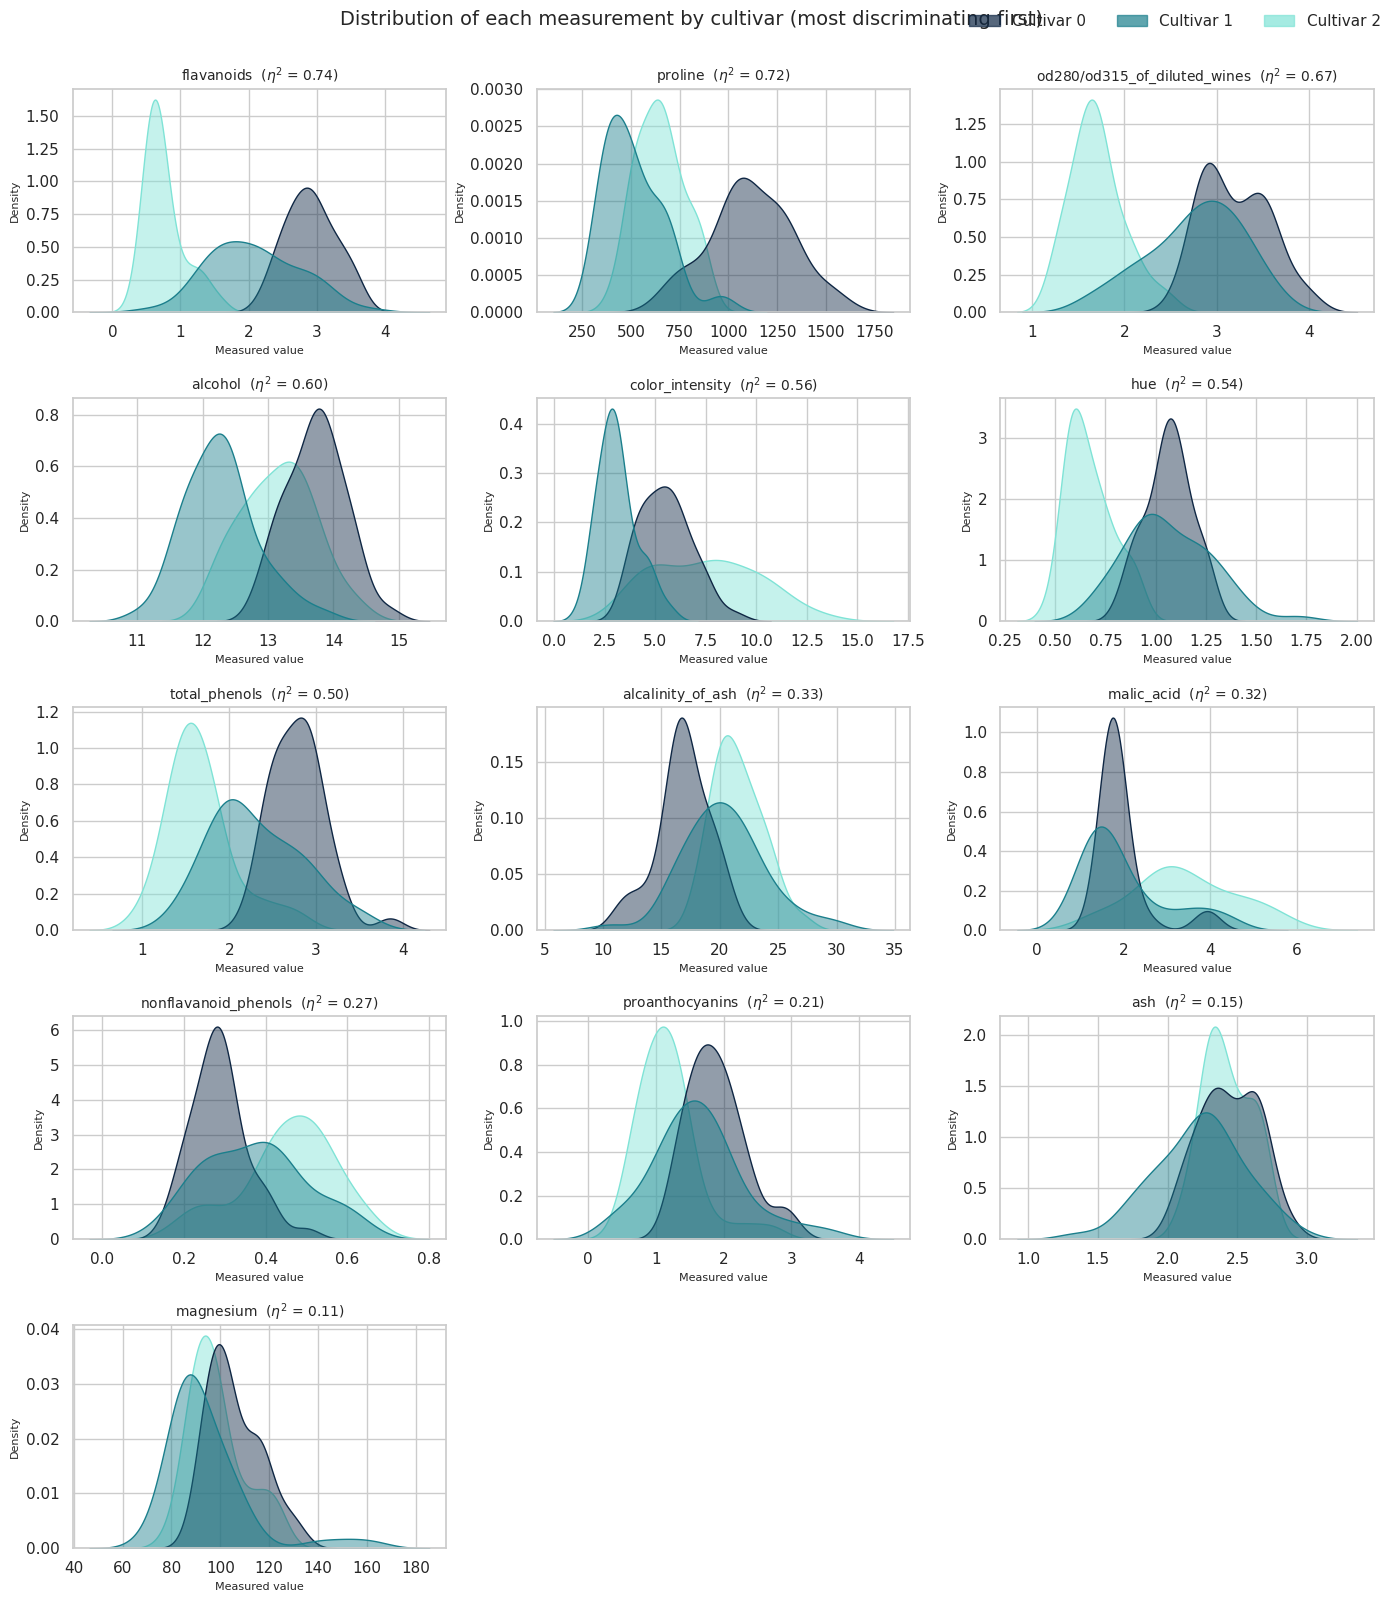

In [7]:
order = eta.index.tolist()  # most discriminating first
n_cols = 3
n_rows = int(np.ceil(len(order) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.2))
axes = axes.flatten()
for ax, col in zip(axes, order):
    sns.kdeplot(data=train, x=col, hue="cultivar", palette=PALETTE, fill=True, alpha=0.45,
                common_norm=False, ax=ax, legend=False)
    ax.set_title(f"{col}  ($\\eta^2$ = {eta[col]:.2f})", fontsize=10)
    ax.set_xlabel("Measured value", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
for ax in axes[len(order):]:
    ax.set_visible(False)
fig.legend(handles=[Patch(color=c, label=l, alpha=0.7) for l, c in PALETTE.items()],
           loc="upper right", ncol=3, frameon=False)
plt.suptitle("Distribution of each measurement by cultivar (most discriminating first)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 The three most discriminating measurements

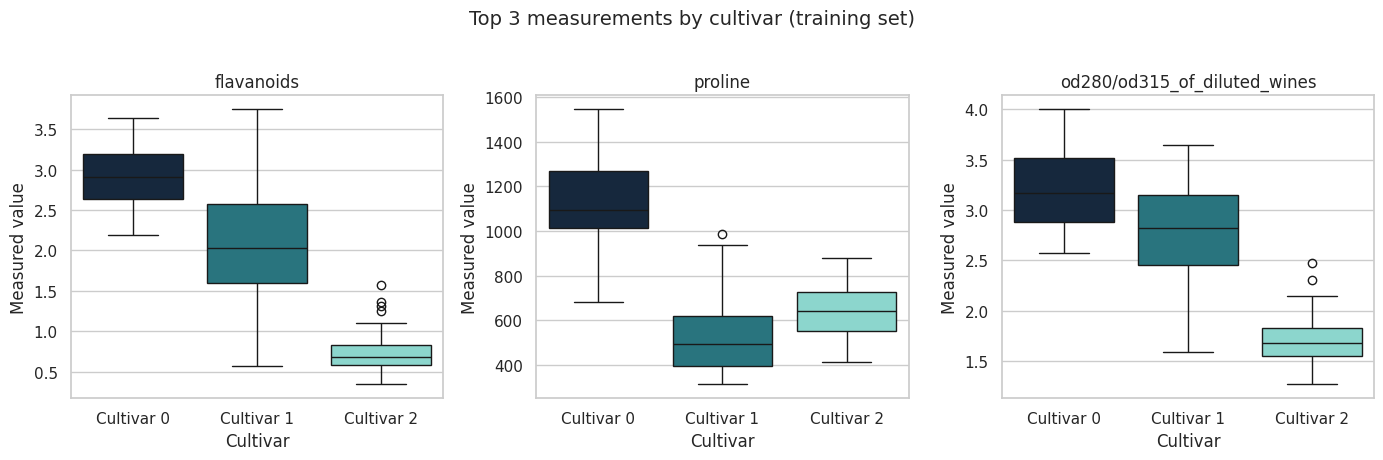

flavanoids        proline         od280/od315_of_diluted_wines  \
                 mean   std     mean     std                         mean   
cultivar                                                                    
Cultivar 0       2.91  0.37  1111.51  208.78                         3.20   
Cultivar 1       2.09  0.66   514.84  152.43                         2.76   
Cultivar 2       0.76  0.29   648.18  121.16                         1.70   

                  
             std  
cultivar          
Cultivar 0  0.36  
Cultivar 1  0.51  
Cultivar 2  0.29

In [8]:
top3 = eta.index[:3].tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, top3):
    sns.boxplot(data=train, x="cultivar", y=col, order=list(PALETTE), palette=PALETTE, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Cultivar")
    ax.set_ylabel("Measured value")
plt.suptitle("Top 3 measurements by cultivar (training set)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

train.groupby("cultivar")[top3].agg(["mean", "std"]).round(2)

**Takeaway.** The three measurements that separate the cultivars best are **flavanoids** ($\eta^2$ = 0.74), **proline** (0.72) and the **OD280/OD315 ratio** (0.67). The weakest are `magnesium` (0.11) and `ash` (0.15), which say very little about the cultivar.

Each cultivar has a recognisable profile:

- **Cultivar 0:** much higher proline (about 1,110, against 515-650 for the others), high flavanoids (2.9) and the highest alcohol (13.7).
- **Cultivar 1:** the lowest alcohol (12.3) and the lowest colour intensity (3.1).
- **Cultivar 2:** very low flavanoids (0.76), the lowest hue and OD280 ratio, and the highest colour intensity (7.5).

No single measurement tells all three cultivars apart. Flavanoids single out Cultivar 2, while proline singles out Cultivar 0 and blurs the other two. It is the **combination** of measurements that makes the cultivars recognisable.

### 3.5 Are some measurements redundant?
Here the correlation is computed **between measurements only** (the class label is left out). Strongly correlated measurements carry overlapping information.

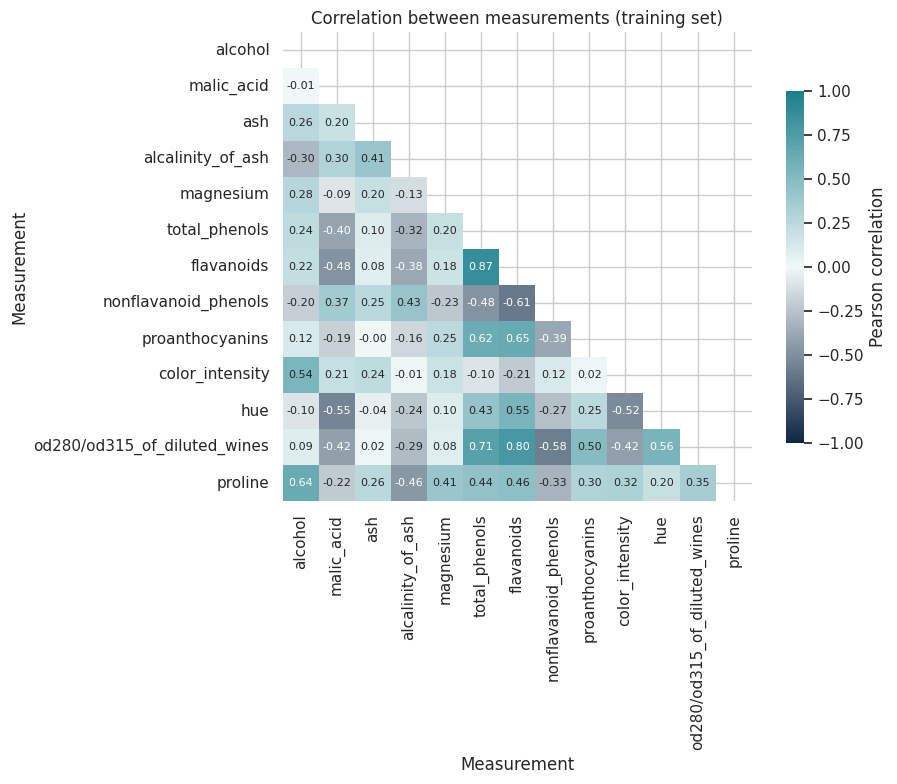

,measurement_1,measurement_2,correlation
83,flavanoids,total_phenols,0.87
149,od280/od315_of_diluted_wines,flavanoids,0.80
148,od280/od315_of_diluted_wines,total_phenols,0.71


In [9]:
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = LinearSegmentedColormap.from_list("navy_teal", ["#0f2744", "#f1f8f8", "#1b7f8c"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", annot_kws={"size": 8}, cmap=cmap, center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.75, "label": "Pearson correlation"}, ax=ax)
ax.set_xlabel("Measurement")
ax.set_ylabel("Measurement")
ax.set_title("Correlation between measurements (training set)")
plt.tight_layout()
plt.show()

pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool)).stack()
         .rename("correlation").reset_index())
pairs.columns = ["measurement_1", "measurement_2", "correlation"]
pairs.loc[pairs["correlation"].abs() >= 0.7].sort_values("correlation", key=abs, ascending=False).round(2)

**Takeaway.** Only three pairs of measurements are strongly related ($|r| \geq 0.7$), and all of them involve phenols: flavanoids and total phenols (0.87), OD280 and flavanoids (0.80), OD280 and total phenols (0.71). These overlap partly because they measure related chemistry. Most of the other measurements are not strongly related to each other, so overall there is little redundancy.

### 3.6 Unusual values
A value is flagged as unusual if it lies outside.
This is measured instead of assumed.

In [10]:
q1, q3 = X_train.quantile(0.25), X_train.quantile(0.75)
iqr = q3 - q1
outlier_mask = (X_train < q1 - 1.5 * iqr) | (X_train > q3 + 1.5 * iqr)
outlier_summary = pd.DataFrame({
    "Unusual values": outlier_mask.sum(),
    "% of wines": (outlier_mask.mean() * 100).round(1),
}).sort_values("Unusual values", ascending=False)

print(f"Wines with at least one unusual value: {int(outlier_mask.any(axis=1).sum())} of {len(X_train)} "
      f"({outlier_mask.any(axis=1).mean() * 100:.0f}%)")
outlier_summary[outlier_summary["Unusual values"] > 0]

Wines with at least one unusual value: 13 of 124 (10%)


,Unusual values,% of wines
magnesium,4,3.2
color_intensity,3,2.4
alcalinity_of_ash,2,1.6
proanthocyanins,2,1.6
malic_acid,2,1.6
hue,1,0.8
ash,1,0.8


**Takeaway.** Only 13 of the 124 training wines (10%) have at least one unusual value, mostly in `magnesium` (4 wines) and `color_intensity` (3 wines). Nothing suggests measurement errors: these look like natural variation between wines. With so few wines, removing any of them would cost information, so **no values were removed**.

## 4. Evaluation set-up
**Metrics.** The classes are balanced, so **accuracy** is the main metric. **Macro-F1** is reported next to it as a check, since it gives each cultivar the same weight.
**Protocol.** Models are compared with 5-fold stratified cross-validation repeated 5 times on the training set (25 scores per model). On 124 training wines a single 5-fold run would be too noisy, and repeating it shows how much each score varies. Standardization sits inside a `Pipeline`, so each fold fits its own scaler and nothing leaks from the validation fold.

**Reference points.** Two naive rules (always predict the most frequent cultivar, and guess at random according to the class shares) show what "learning nothing" scores. Any model must beat them clearly to be worth using.

In [11]:
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

def evaluate_cv(models, X, y):
    """Cross-validate each model; returns a summary table (with timings) and the per-fold accuracies."""
    rows, accs = [], {}
    for name, model in models.items():
        res = cross_validate(model, X, y, cv=CV, n_jobs=1,
                             scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"})
        accs[name] = res["test_accuracy"]
        rows.append({
            "Model": name,
            "Accuracy (mean)": res["test_accuracy"].mean(),
            "Accuracy (std)": res["test_accuracy"].std(),
            "Macro-F1 (mean)": res["test_f1_macro"].mean(),
            "Fit time / fold (ms)": res["fit_time"].mean() * 1000,
            "Predict time / fold (ms)": res["score_time"].mean() * 1000,
        })
    return pd.DataFrame(rows).set_index("Model"), accs

def scaled(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

models = {
    "Naive rule: most frequent": DummyClassifier(strategy="most_frequent"),
    "Naive rule: random by class share": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "KNN, measurements NOT scaled": KNeighborsClassifier(),
    "KNN, scaled": scaled(KNeighborsClassifier()),
    "Logistic Regression, scaled": scaled(LogisticRegression(max_iter=1000)),
}
cv_table, cv_accs = evaluate_cv(models, X_train, y_train)
cv_table.round(3)

,Accuracy (mean),Accuracy (std),Macro-F1 (mean),Fit time / fold (ms),Predict time / fold (ms)
Model,,,,,
Naive rule: most frequent,0.403,0.007,0.192,0.627,2.404
Naive rule: random by class share,0.322,0.081,0.298,0.598,2.912
"KNN, measurements NOT scaled",0.743,0.079,0.733,2.455,6.500
"KNN, scaled",0.950,0.042,0.953,3.822,5.497
"Logistic Regression, scaled",0.982,0.026,0.984,6.191,4.528


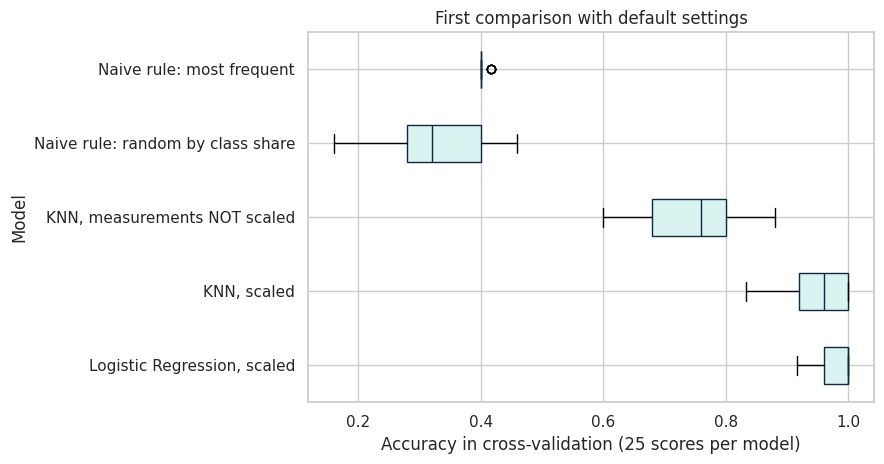

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.boxplot(list(cv_accs.values()), vert=False, patch_artist=True,
           boxprops=dict(facecolor="#d8f3f0", color="#0f2744"), medianprops=dict(color="#0f2744"))
ax.set_yticklabels(list(cv_accs.keys()))
ax.invert_yaxis()
ax.set_xlabel("Accuracy in cross-validation (25 scores per model)")
ax.set_ylabel("Model")
ax.set_title("First comparison with default settings")
plt.tight_layout()
plt.show()

**Takeaway.**

- **Every real model beats the naive rules by a wide margin:** 95-98% accuracy, against 40% for "always the most frequent cultivar" and 32% for random guessing.
- **Preparing the data matters a lot.** The same KNN falls from **95.0% to 74.3%** accuracy when the measurements are not scaled, because `proline` (values in the hundreds) overwhelms measurements such as `hue` (around 1). This confirms, with data, the assumption made earlier.
- **Logistic Regression is already at 98.2%** with default settings, slightly above KNN (95.0%).

## 5. Tuning the two models
Both models get a small hyperparameter search with the same repeated cross-validation, and the search time is recorded.

- **K-Nearest Neighbors** classifies a wine by looking at its most similar wines. Searched: number of neighbours (1 to 20), uniform or distance weighting, Euclidean or Manhattan distance.
- **Logistic Regression** is a linear model. Searched: regularization strength $C$.

In [13]:
knn_search = GridSearchCV(
    scaled(KNeighborsClassifier()),
    {"model__n_neighbors": range(1, 21),
     "model__weights": ["uniform", "distance"],
     "model__metric": ["euclidean", "manhattan"]},
    cv=CV, scoring="accuracy", n_jobs=-1)
t0 = time.perf_counter(); knn_search.fit(X_train, y_train); knn_time = time.perf_counter() - t0

lr_search = GridSearchCV(
    scaled(LogisticRegression(max_iter=1000)),
    {"model__C": [0.01, 0.1, 1, 10, 100]},
    cv=CV, scoring="accuracy", n_jobs=-1)
t0 = time.perf_counter(); lr_search.fit(X_train, y_train); lr_time = time.perf_counter() - t0

print(f"KNN                 best CV accuracy {knn_search.best_score_:.3f}  |  search time {knn_time:5.1f}s  |  {knn_search.best_params_}")
print(f"Logistic Regression best CV accuracy {lr_search.best_score_:.3f}  |  search time {lr_time:5.1f}s  |  {lr_search.best_params_}")

KNN                 best CV accuracy 0.971  |  search time  14.6s  |  {'model__metric': 'manhattan', 'model__n_neighbors': 1, 'model__weights': 'uniform'}
Logistic Regression best CV accuracy 0.987  |  search time   1.2s  |  {'model__C': 100}


Before reading anything into the "best" settings, we check how much they actually matter:

KNN configurations tested: 80
Tied with the best score:            3
Within 1 percentage point of best:   10
Best Euclidean: 0.961 | best Manhattan: 0.971


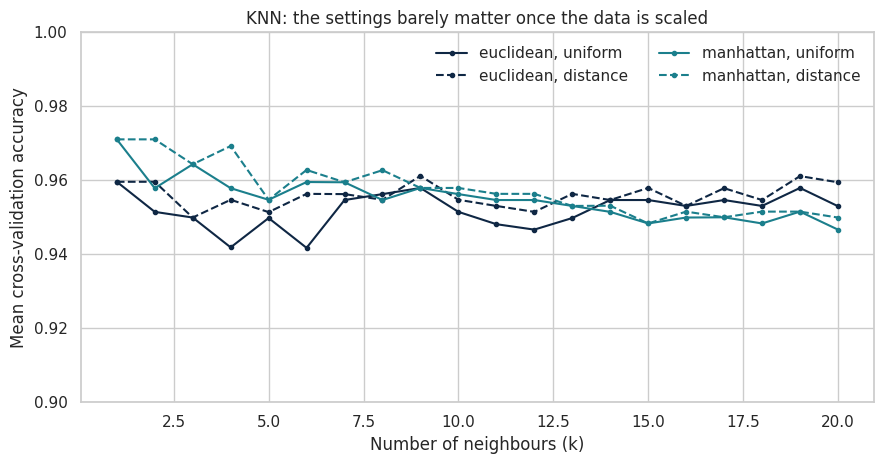

In [14]:
res = pd.DataFrame(knn_search.cv_results_)
best = res["mean_test_score"].max()
print(f"KNN configurations tested: {len(res)}")
print(f"Tied with the best score:            {int((res['mean_test_score'] >= best - 1e-9).sum())}")
print(f"Within 1 percentage point of best:   {int((res['mean_test_score'] >= best - 0.01).sum())}")
print(f"Best Euclidean: {res[res['param_model__metric'] == 'euclidean']['mean_test_score'].max():.3f} | "
      f"best Manhattan: {res[res['param_model__metric'] == 'manhattan']['mean_test_score'].max():.3f}")

fig, ax = plt.subplots(figsize=(9, 4.8))
styles = {("euclidean", "uniform"): ("#0f2744", "-"), ("euclidean", "distance"): ("#0f2744", "--"),
          ("manhattan", "uniform"): ("#1b7f8c", "-"), ("manhattan", "distance"): ("#1b7f8c", "--")}
for (metric, weights), (color, ls) in styles.items():
    sub = res[(res["param_model__metric"] == metric) & (res["param_model__weights"] == weights)]
    ax.plot(sub["param_model__n_neighbors"], sub["mean_test_score"], color=color, ls=ls, marker="o",
            ms=3, label=f"{metric}, {weights}")
ax.set_xlabel("Number of neighbours (k)")
ax.set_ylabel("Mean cross-validation accuracy")
ax.set_ylim(0.90, 1.0)
ax.set_title("KNN: the settings barely matter once the data is scaled")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

**Takeaway.** The search picked KNN with $k=1$, Manhattan distance (cross-validation accuracy 0.971) and Logistic Regression with $C=100$ (0.987). But the specific KNN settings should not be over-interpreted:

- only 3 of the 80 configurations tie for the best score, and **10 are within one percentage point** of it;
- the best Euclidean setting (0.961) and the best Manhattan setting (0.971) differ by about one point, less than the typical fold-to-fold variation (2-4 points);
- $k=1$ is the most flexible setting and was chosen out of 80 tries on a small sample, so part of its advantage is probably chance.

In short, once the data is scaled, KNN works about equally well across many settings. Tuning also took about 14 s for KNN against about 1 s for Logistic Regression (timings depend on the machine).

## 6. Final evaluation on the test set
The test set is used **once**, after all choices are made. The naive rules and the unscaled KNN are shown next to the tuned models for reference.

In [15]:
unscaled_knn = KNeighborsClassifier().fit(X_train, y_train)
dummy_freq = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

final_models = {
    "Naive rule: most frequent": dummy_freq,
    "KNN, measurements NOT scaled (k=5)": unscaled_knn,
    "KNN, scaled and tuned": knn_search.best_estimator_,
    "Logistic Regression, scaled and tuned": lr_search.best_estimator_,
}
rows, preds = [], {}
for name, model in final_models.items():
    t0 = time.perf_counter(); pred = model.predict(X_test); ms = (time.perf_counter() - t0) * 1000
    preds[name] = pred
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred),
                 "Macro-F1": f1_score(y_test, pred, average="macro"),
                 f"Predict {len(X_test)} wines (ms)": ms})
test_table = pd.DataFrame(rows).set_index("Model")
test_table.round(3)

,Accuracy,Macro-F1,Predict 54 wines (ms)
Model,,,
Naive rule: most frequent,0.389,0.187,0.095
"KNN, measurements NOT scaled (k=5)",0.574,0.560,2.823
"KNN, scaled and tuned",1.000,1.000,3.602
"Logistic Regression, scaled and tuned",0.963,0.962,1.843


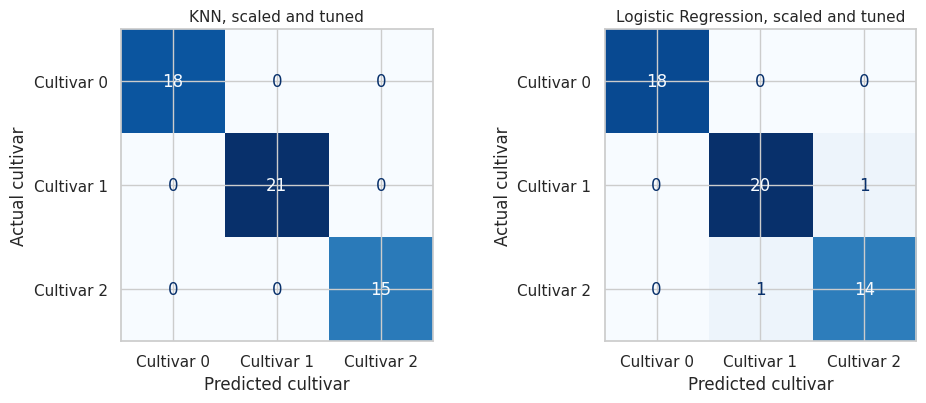

              precision    recall  f1-score   support

  Cultivar 0       1.00      1.00      1.00        18
  Cultivar 1       1.00      1.00      1.00        21
  Cultivar 2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [16]:
names = ["KNN, scaled and tuned", "Logistic Regression, scaled and tuned"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, name in zip(axes, names):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=list(CULTIVARS.values())).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_xlabel("Predicted cultivar")
    ax.set_ylabel("Actual cultivar")
    ax.set_title(name, fontsize=11)
plt.tight_layout()
plt.show()

print(classification_report(y_test, preds["KNN, scaled and tuned"], target_names=list(CULTIVARS.values())))

**Takeaway.** On the 54 test wines, the tuned KNN classified **all 54 correctly (100%)** and Logistic Regression got 52 right (96.3%). The unscaled KNN reached only 57.4% and the naive rule 38.9%. Every model predicts the 54 wines in a few milliseconds.

The 100% should be read with care, for two reasons. First, one wine is worth 1.9 percentage points here, so the 3.7-point gap between the two models is a difference of **two wines**. Second, during cross-validation on the training set Logistic Regression scored *higher* than KNN (0.987 against 0.971), so the perfect KNN score is not evidence that it is the better model. The next section shows how much a single split can move the result.

## 7. How much does the test score depend on the split?
With only 54 test wines, one score can be lucky. To see how much the result moves, the same comparison is repeated on **20 different random splits** (default settings, so no tuning is shared between splits), and the test accuracy is recorded each time.

In [17]:
SEEDS = list(range(100, 120))
seed_models = {
    "Naive rule: most frequent": lambda: DummyClassifier(strategy="most_frequent"),
    "KNN, measurements NOT scaled": lambda: KNeighborsClassifier(),
    "KNN, scaled": lambda: scaled(KNeighborsClassifier()),
    "Logistic Regression, scaled": lambda: scaled(LogisticRegression(max_iter=1000)),
}
seed_rows = []
for seed in SEEDS:
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.30, stratify=y, random_state=seed)
    for name, make in seed_models.items():
        seed_rows.append({"seed": seed, "Model": name,
                          "accuracy": accuracy_score(yb, make().fit(Xa, ya).predict(Xb))})
seed_df = pd.DataFrame(seed_rows)

summary = seed_df.groupby("Model")["accuracy"].agg(
    Mean="mean", Std="std", Min="min", Max="max",
    **{"% of splits at 100%": lambda s: 100 * (s == 1).mean()}).loc[list(seed_models)]
summary.round(3)

,Mean,Std,Min,Max,% of splits at 100%
Model,,,,,
Naive rule: most frequent,0.389,0.000,0.389,0.389,0.0
"KNN, measurements NOT scaled",0.710,0.039,0.630,0.778,0.0
"KNN, scaled",0.962,0.023,0.907,1.000,5.0
"Logistic Regression, scaled",0.981,0.013,0.963,1.000,25.0


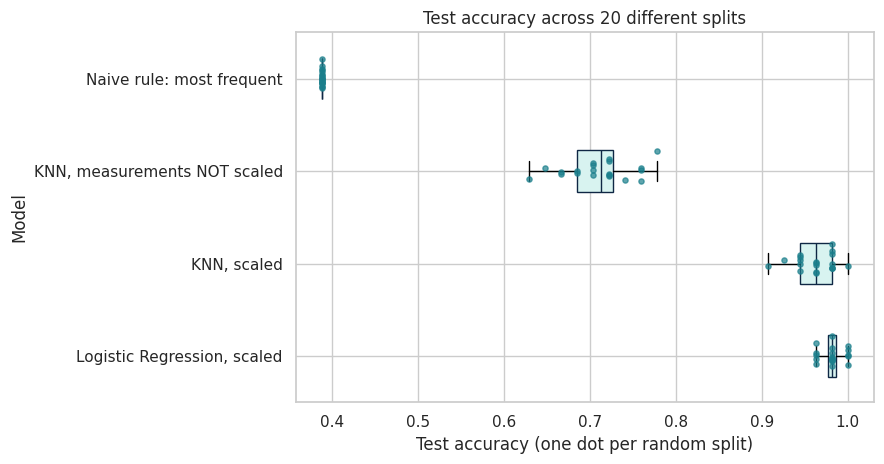

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.8))
data = [seed_df.loc[seed_df["Model"] == m, "accuracy"] for m in seed_models]
ax.boxplot(data, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#d8f3f0", color="#0f2744"), medianprops=dict(color="#0f2744"))
for i, d in enumerate(data, start=1):
    ax.scatter(d, np.random.RandomState(RANDOM_STATE).normal(i, 0.06, len(d)), s=14, color="#1b7f8c", alpha=0.7, zorder=3)
ax.set_yticklabels(list(seed_models))
ax.invert_yaxis()
ax.set_xlabel("Test accuracy (one dot per random split)")
ax.set_ylabel("Model")
ax.set_title("Test accuracy across 20 different splits")
plt.tight_layout()
plt.show()

**Takeaway.** Across 20 different splits:

- **Logistic Regression** averages **98.1%** (range 96.3-100%) and reaches 100% in 25% of the splits.
- **KNN, scaled** averages **96.2%** (range 90.7-100%) and reaches 100% in only 5% of the splits.
- **KNN, unscaled** averages 71.0% and never gets above 77.8%. The naive rule stays at 38.9%.

So a perfect score is largely a matter of which wines land in the test set. A realistic expectation for the scaled models is **about 96-98% accuracy**, and Logistic Regression is slightly higher and steadier (spread of 1.3 points against 2.3 for KNN).

## 8. Conclusions

**Can the lab recognise the cultivar from its chemical analysis? Yes, quite reliably.** A simple model identifies the cultivar correctly about **96-98% of the time**, against about 40% for a rule that always names the most frequent cultivar.

**Which measurements matter most?** Flavanoids, proline and the OD280/OD315 ratio separate the cultivars best, and each cultivar has a distinct chemical profile (high proline for Cultivar 0, low alcohol and colour for Cultivar 1, very low flavanoids for Cultivar 2). No single measurement is enough: it is the combination that works.

**How much does data preparation matter?** A great deal. Without scaling the measurements, KNN loses about 20 points of accuracy (95.0% to 74.3% in cross-validation).

**Which model would I recommend?** Logistic Regression. It is simple, fast to tune, and as accurate as KNN or slightly better in every fair comparison (98.7% against 97.1% in tuned cross-validation, and 98.1% against 96.2% on average across 20 splits). The 100% obtained by KNN on the original test set came from a favourable split, not from a better model.

**Before any real use,** the model should be validated on new wines from other years, regions or laboratories, since this dataset is small and its classes are unusually easy to separate.